In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
# from upsetplot import from_contents, plot
from matplotlib import pyplot

from pathlib import Path

from dfmodel import DigitalFamilyBinary
from networkx.classes import non_neighbors

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial")

In [39]:
design_matrix_test = pd.read_csv(
    "../0_clinical_data/design_matrix_test.tsv",
    sep='\t'
)

In [40]:
design_matrix = pd.read_csv(
    "../0_clinical_data/design_matrix_train.tsv",
    sep='\t'
)

In [41]:
design_matrix['temperature_ambulance'].min()

34.0

In [42]:
design_matrix_test['temperature_ambulance'].min()

32.0

In [43]:
design_matrix['survival_days'] = design_matrix['survival_days'].fillna(design_matrix['survival_days'].max())

In [44]:
design_matrix_test['survival_days'] = design_matrix_test['survival_days'].fillna(design_matrix_test['survival_days'].max())

In [45]:
design_matrix['organ_dysfunction'] = ((design_matrix[['sofa_score_increase_day1', 'sofa_score_increase_day2', 'sofa_score_increase_day3']] > 1).any(axis=1)).astype(int)
design_matrix_test['organ_dysfunction'] = ((design_matrix_test[['sofa_score_increase_day1', 'sofa_score_increase_day2', 'sofa_score_increase_day3']] > 1).any(axis=1)).astype(int)

In [46]:
design_matrix.shape

(680, 72)

In [47]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age"
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age"
]

categorical_clinical_columns = [
    "mental_status_ambulance",
]

In [48]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer, MinMaxScaler
from sklearn.impute import SimpleImputer

training_data = design_matrix.copy()
testing_data = design_matrix_test.copy()

clinical_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
min_max_scaler = MinMaxScaler()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

training_data[continuous_clinical_columns] = clinical_imputer.fit_transform(training_data[continuous_clinical_columns])
training_data[["mental_status_ambulance"]] = constant_imputer.fit_transform(training_data[["mental_status_ambulance"]])

training_data[continuous_clinical_columns] = clinical_scaler.fit_transform(training_data[continuous_clinical_columns])
training_data[['sex']] = sex_scaler.fit_transform(training_data[['sex']])
#training_data[clinical_columns] = min_max_scaler.fit_transform(training_data[clinical_columns])

testing_data[continuous_clinical_columns] = clinical_imputer.transform(testing_data[continuous_clinical_columns])
testing_data[["mental_status_ambulance"]] = constant_imputer.transform(testing_data[["mental_status_ambulance"]])

testing_data[continuous_clinical_columns] = clinical_scaler.transform(testing_data[continuous_clinical_columns])
testing_data[['sex']] = sex_scaler.transform(testing_data[['sex']])
#testing_data[clinical_columns] = min_max_scaler.transform(testing_data[clinical_columns])

In [49]:
training_data['label'] = "training"
testing_data['label'] = "testing"

In [50]:
training_data = pd.concat(
    [training_data, testing_data]
).reset_index(drop=True)

In [51]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(training_data[clinical_columns])

training_data['PCA 1'] = components[:, 0]
training_data['PCA 2'] = components[:, 1]

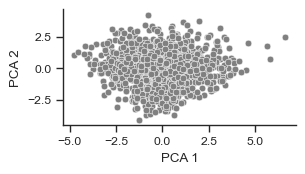

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

sns.scatterplot(
    data=training_data,
    x='PCA 1',
    y='PCA 2',
    ax=ax,
    c="gray"
)

sns.despine()

fig.set_size_inches(
    (3, 1.5)
)

fig.savefig(
    "sepsis_or_septic_shock.pdf", dpi=300, bbox_inches="tight"
)

In [16]:
from sklearn.cluster import OPTICS

optcs_model = OPTICS(
    min_samples=10,
)

optcs_model.fit(training_data[clinical_columns])

,min_samples,10
,max_eps,inf
,metric,'minkowski'
,p,2
,metric_params,None
,cluster_method,'xi'
,eps,None
,xi,0.05
,predecessor_correction,True
,min_cluster_size,None
,algorithm,'auto'


In [17]:
optics_results = pd.DataFrame(
    {
        "sample": training_data.index.values,
        "reachability": optcs_model.reachability_[optcs_model.ordering_],
        "label": optcs_model.labels_[optcs_model.ordering_],
    }
)

In [18]:
optics_results.to_csv(
    "optics_results.csv", index=False
)

In [19]:
optics_results['label'].value_counts()

label
0    1360
Name: count, dtype: int64

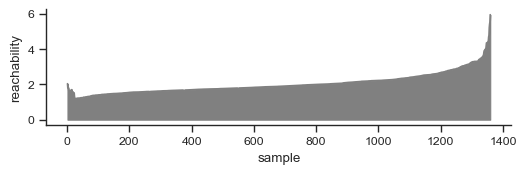

In [65]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

sns.lineplot(
    data=optics_results,
    x="sample",
    y="reachability",
    ax=ax,
    c="gray"
)

ax.fill_between(
    optics_results['sample'],
    optics_results['reachability'],
    #alpha=0.3,
    color="gray"
)

sns.despine()

fig.set_size_inches(
    (6, 1.5)
)

fig.savefig(
    "optics_results.pdf", dpi=300, bbox_inches="tight"
)

In [21]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans

class ConsensusClustering:

    def __init__(self, n_clusters=2, random_state=0, n_runs=20, subsample=0.9):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.n_runs = n_runs
        self.subsample = subsample

    def fit_transform(self, X: pd.DataFrame):

        self.coassoc_matrix = np.zeros((X.shape[0], X.shape[0]))

        for run in range(self.n_runs):

            X_ = X.sample(frac=self.subsample, replace=False)

            kmeans = KMeans(n_clusters=self.n_clusters, random_state=self.random_state)

            labels = kmeans.fit_predict(X_)

            for i, idxi in enumerate(X_.index):

                for j, idxj in enumerate(X_.index):

                    if labels[i] == labels[j]:

                        self.coassoc_matrix[idxi, idxj] += 1

        self.coassoc_matrix /= self.n_runs

        linked = linkage(1 - self.coassoc_matrix, method="average")

        return fcluster(linked, t=self.n_clusters, criterion="maxclust")



In [22]:
from scipy.stats import ecdf
from statsmodels.distributions.empirical_distribution import ECDF

clusterer_results = dict()

cdfs = dict()

range_n_clusters = range(2, 11)

for n_cluster in range_n_clusters:

    consensus_clusterer = ConsensusClustering(
        n_clusters=n_cluster,
        n_runs=1000,
        random_state=0,
    )

    training_data[f'Consensus Labels{n_cluster}'] = consensus_clusterer.fit_transform(training_data[clinical_columns])

    clusterer_results[n_cluster] = consensus_clusterer

    consensus_values = consensus_clusterer.coassoc_matrix[np.triu_indices_from(consensus_clusterer.coassoc_matrix, k=1)]

    cdfs[n_cluster] = (ECDF(consensus_values)(np.arange(0.0, 1.0, 0.01)), np.arange(0.0, 1.0, 0.01), consensus_values)#ecdf(consensus_values)


In [23]:
pallete = sns.color_palette(
    "twilight_shifted_r", n_colors=11
)

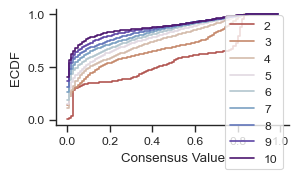

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

plot_data = pd.DataFrame()

for k, cdf in cdfs.items():

    sns.lineplot(
        x=cdf[1],
        y=cdf[0],
        ax=ax,
        label=k,
        color=pallete[k],
        drawstyle="steps-post",
        #linewidth=2,
    )

    temp_df = pd.DataFrame(
        {
            "Consensus Value": cdf[1],
            "ECDF": cdf[0],
            "K": [k for _ in range(len(cdf[0]))],
        }
    )

    plot_data = pd.concat([plot_data, temp_df])

sns.despine()

ax.set_xlabel("Consensus Value")
ax.set_ylabel("ECDF")

fig.set_size_inches(
    (3, 1.5)
)

fig.savefig(
    "cdfs.pdf", dpi=300, bbox_inches="tight"
)


In [25]:

auc_data = []

for k, cdf in cdfs.items():

    auc_data.append(np.trapz(cdf[0], cdf[1]))

In [26]:
auc_deltas = []

for left, right in zip(auc_data[:-1], auc_data[1:]):

    auc_delta = right - left

    auc_deltas.append(auc_delta)



In [27]:
auc_plot_data = pd.DataFrame(
    {
        "AUC": auc_deltas,
        "K": range(len(auc_deltas)),
    }
)

auc_plot_data.to_csv(
    "auc_plot.csv",
    index=False,
)

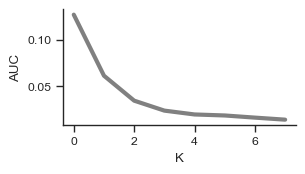

In [28]:
fig, ax = plt.subplots()

sns.lineplot(
    data=auc_plot_data,
    x="K",
    y="AUC",
    ax=ax,
    c="gray",
    lw=3
)

sns.despine()

fig.set_size_inches(
    (3, 1.5)
)



fig.savefig(
    "auc_plot.pdf", dpi=300, bbox_inches="tight"
)

In [29]:
plot_data = pd.DataFrame()

for k, cdf in cdfs.items():

    temp_df = pd.DataFrame(
        {
            "Consensus Values": cdf[2],
            "K": [k for _ in range(len(cdf[2]))],
        }
    )

    plot_data = pd.concat([plot_data, temp_df])

In [30]:
plot_data.to_csv(
    "consensus_values_density.csv",
    index=False,
)

/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_23659/4087620511.py:3: UserWarning: The palette list has more values (11) than needed (9), which may not be intended.
  sns.kdeplot(


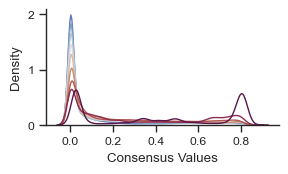

In [31]:
fig, ax = plt.subplots()

sns.kdeplot(
    data=plot_data,
    x="Consensus Values",
    hue="K",
    palette=pallete,
    ax=ax,
    lw=1,
    legend=False,
)
sns.despine()

fig.set_size_inches(
    (3, 1.5)
)

fig.savefig(
    "kdeplot.pdf", dpi=300, bbox_inches="tight"
)

In [32]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range_n_clusters:

    col = f"Consensus Labels{k}"

    silhouette_scores.append(silhouette_score(training_data[clinical_columns], training_data[col]))


In [33]:
silhouette_scores_results = pd.DataFrame(
    {
        "n_cluster": range_n_clusters,
        "silhouette_score": silhouette_scores,
    }
)

silhouette_scores_results.to_csv(
    "silhouette_scores.csv",
    index=False,
)

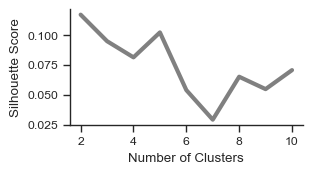

In [34]:
fig, ax = plt.subplots()

sns.lineplot(
    data=silhouette_scores_results,
    x="n_cluster",
    y="silhouette_score",
    ax=ax,
    c="gray",
    lw=3
)

sns.despine()

fig.set_size_inches(
    (3, 1.5)
)

ax.set_xlabel("Number of Clusters")
ax.set_ylabel("Silhouette Score")
fig.savefig(
    "silhouette.pdf", dpi=300, bbox_inches="tight"
)

2


/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


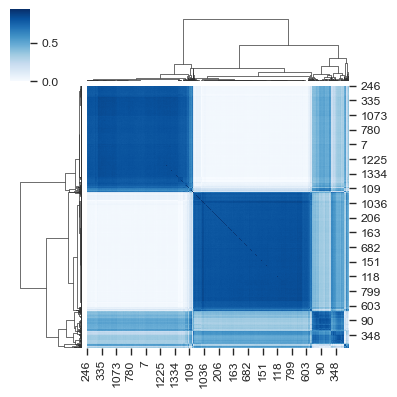

3


/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


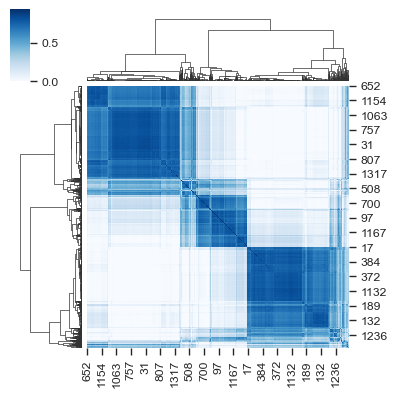

4


/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


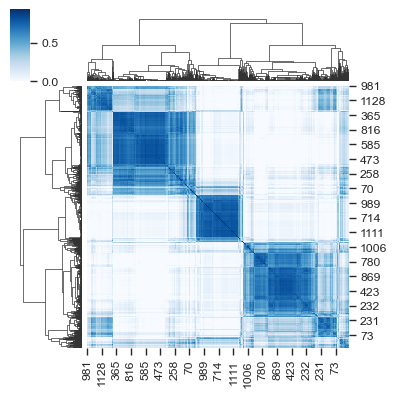

5


/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


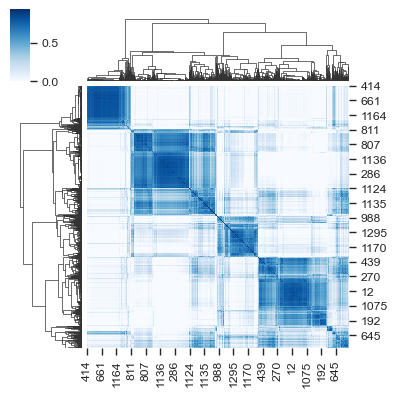

6


/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


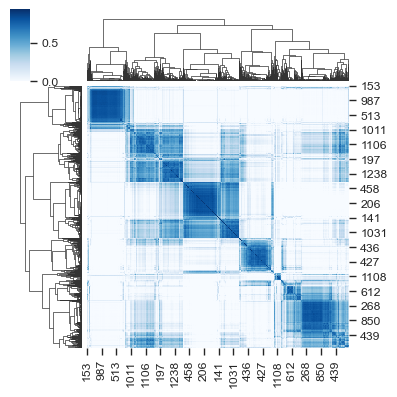

7


/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


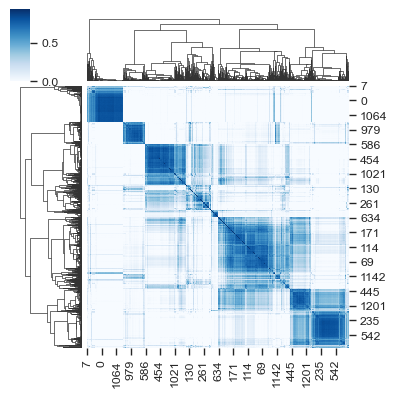

8


/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


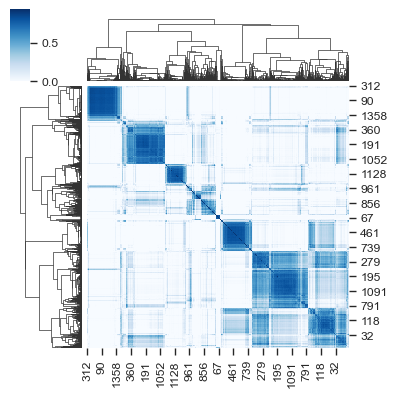

9


/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


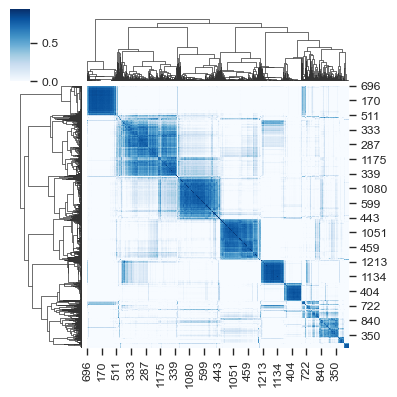

10


/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


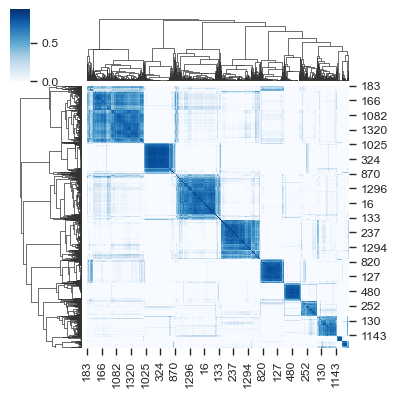

In [35]:
for k in clusterer_results.keys():

    print(k)
    g = sns.clustermap(
        data=clusterer_results[k].coassoc_matrix,
        cmap="Blues",
        figsize=(4, 4),
    )

    g.savefig(
        f"cluster_results-{k}.pdf",
        dpi=300,
        bbox_inches="tight",
    )

    pd.DataFrame(
        clusterer_results[k].coassoc_matrix
    ).to_csv(
        f"cluster_results_{k}.csv",
        index=False,
    )

    plt.show()


In [36]:
training_data.to_csv(
    "cluster_results.csv",
    index=False,
)

In [37]:
from joblib import dump

with open("pca.pickle", "wb") as f:
    dump(pca, f)